In [250]:
import os
from langchain_core.prompts import ChatPromptTemplate
from dotenv import load_dotenv
from langchain.tools import tool
load_dotenv()

if os.environ["GOOGLE_API_KEY"]:
    print("GOOGLE_API_KEY is set")
else:
    raise ValueError("GOOGLE_API_KEY is not set")

GOOGLE_API_KEY is set


In [251]:
from langchain_core.messages import HumanMessage,ToolMessage
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite",
    temperature=1.0,  # Gemini 3.0+ defaults to 1.0
    max_tokens=None,
    timeout=None,
    max_retries=2,
    # other params...
)

## tools

**duclkduckgo_search**

In [252]:
from langchain_community.tools import DuckDuckGoSearchRun



@tool
def duckduckgo_search(query : str)->str:
    """this tool search for anything"""
    duckduckgo_search = DuckDuckGoSearchRun()
    return duckduckgo_search.invoke(query)


In [253]:
from langchain_community.retrievers import ArxivRetriever


@tool
def arxiv_search(query : str)->str:
    """this tool arxiv query for research paper"""
    arxiv_retriever = ArxivRetriever()
    return arxiv_retriever.invoke(query)




In [254]:
from langchain_community.retrievers import WikipediaRetriever
@tool
def wiki_tool(query : str)-> str:
    """this tool search for wikipedia"""
    wiki_retriever = WikipediaRetriever()
    docs = wiki_retriever.invoke(query)
    return docs[0].page_content



## custom tool


In [255]:

@tool
def personal_tool(name: str)->str:

    """use this tool to get personal information about a person"""

    info={
    "alice": "Alice is a person",
    "bob": "Bob is a person",
    "charlie": "Charlie is a person",
    "dave": "Dave is a person"
    }

    return info.get(name , "no info found")

In [256]:
personal_tool.invoke("alice")

'Alice is a person'

## tool binding

In [257]:
tools = [
    duckduckgo_search,personal_tool,arxiv_search,wiki_tool]

model_with_tools = model.bind_tools(tools)

In [258]:
response = model_with_tools.invoke("what is the personal info for alice")
response.tool_calls

[{'name': 'personal_tool',
  'args': {'name': 'alice'},
  'id': 'a42d9bd5-ea79-4e2e-9bdc-8b98eb3cb09f',
  'type': 'tool_call'}]

## langgraph creation

## create schema

In [259]:
from typing import TypedDict, List

class graph_schema(TypedDict):
    messages: List

## create node function

In [260]:
def model_node(state: graph_schema)-> graph_schema:
    messages = state['messages']
#prompt template for the LLM, including sysytem message and human input
    prompt = ChatPromptTemplate.from_messages([
        ("system","you are a helpful assistant that can use tools to answer questions"),
        ("human","{input}")
    ])

    #llm with tool
    # model_with_tools 

    chain = prompt | model_with_tools

    response = chain.invoke({"input":messages})

    state['messages']=messages + [response]

    return state
    

In [261]:
# from langgraph.prebuilt import ToolNode

# from langgraph.prebuilt import ToolNode
def tool_node(state: graph_schema) -> graph_schema:

    messages = state['messages']

    tools_by_name = {tool.name: tool for tool in tools}

    tool_results = []

    for tool_call in messages[-1].tool_calls:

        tool = tools_by_name[tool_call["name"]]

        observation = tool.invoke(tool_call["args"])

        tool_results.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))

    # Update the state with the tool results
    state['messages'] = messages + tool_results

    return state

In [262]:
# from langgraph.prebuilt import ToolNode
# tool_node = ToolNode(tools)

### create conditional edge function

In [263]:


def if_tool_call(state: graph_schema) -> str:
    last_messages = state['messages'][-1]

    if last_messages.tool_calls:
        return "tool_node"
    else:
        return "end"

## create state graph

In [264]:
from langgraph.graph import StateGraph,START,END

graph = StateGraph(graph_schema)


# add nodes

graph.add_node("model_node",model_node)
graph.add_node("tool_node",tool_node) 


#add edges
graph.add_edge(START,"model_node")

graph.add_conditional_edges("model_node"
                            ,if_tool_call,
                            {"tool_node":"tool_node","end":END
                            }) 

graph.add_edge("tool_node","model_node")

# graph.add_edge("model_node",END)

result_graph = graph.compile()

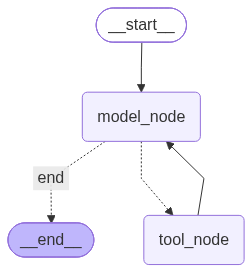

In [265]:
from IPython.display import display,Image

Image(result_graph.get_graph().draw_mermaid_png())

In [ ]:
result_graph.invoke({"messages": [HumanMessage(content="What is the latest news on AI?")]})


{'messages': [HumanMessage(content='What is the latest news on AI?', additional_kwargs={}, response_metadata={}),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'duckduckgo_search', 'arguments': '{"query": "latest news on artificial intelligence 2026"}'}, '__gemini_function_call_thought_signatures__': {'e32a6e65-103d-485d-ba86-d13d52bab342': 'El4KXAERTTIPnBohoxfwRSe8yO4JvT+eBqhKzZrrw6wvARc4VKrApNUJm6Q2KDhON/Uq+kssQU4C5aHsiBqBlHVHBetpo61ZydtH/7EGqUplzfqSVFnSr4Z/ZKezSdlz'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a061bb-c15f-7f23-ad04-753f4c6f6c5b-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'latest news on artificial intelligence 2026'}, 'id': 'e32a6e65-103d-485d-ba86-d13d52bab342', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 213, 'output_tokens': 27, 'total_tokens': 240, 'input_token_details': {'cac

In [267]:
def print_stream(stream):
    for s in stream:
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()

inputs = {"messages": [HumanMessage(content="What is the latest news on AI?")]}

print_stream(result_graph.stream(inputs, stream_mode="values"))

================================ Human Message =================================

What is the latest news on AI?
================================== Ai Message ==================================

[]
Tool Calls:
  duckduckgo_search (364cbf90-ae52-44da-a9ff-2ed37eed4b69)
 Call ID: 364cbf90-ae52-44da-a9ff-2ed37eed4b69
  Args:
    query: latest news on AI 2026
================================= Tool Message =================================

AI News delivers the latest updates in artificial intelligence, machine learning, deep learning, enterprise AI , and emerging tech worldwide.August 25, 2026 . MIT AI forecasts extreme weather without historical data. The latest AI news we announced in August 2026 .Google’s August 2026 updates focus on making artificial intelligence more practical through new hardware like the Pixel 11 series and cost-efficient models like Gemini 3.7 Flash. Follow the latest news on Google Gemini. Read reviews of LLM versions, DeepMind research, Android integrations, and 